# I - Préliminaires - Fonctions utiles

In [1]:
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
import itertools
import numpy as np
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Matrice de confusion',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    from http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html
    :param cm: (numpy matrix) confusion matrix
    :param classes: [str]
    :param normalize: (bool)
    :param title: (str)
    :param cmap: (matplotlib color map)
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(8, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('Vérité Terrain')
    plt.xlabel('Prédiction')

# II - Entraînement d'un CNN pour la classification sur CIFAR10

### II.1. Chargement et Dimensionnement de la base CIFAR10

In [3]:
from keras import backend as K
print(K.backend())

tensorflow


In [4]:
from keras.datasets import cifar10

Réduction de la taille du dataset (pour accélérer l'apprentissage), et standardisation des données

QSTN°1:On divise les données en ensembles d’entraînement, de validation et de test pour entraîner le modèle, ajuster ses hyperparamètres et évaluer ses performances sur des données jamais vues. Cela permet d’éviter le surapprentissage et d’obtenir une évaluation fiable.

QSTN°2: La fonction standardize réalise une normalisation des données.
L'interet de la fonction standarize :
est de rendre l'apprentissage plus  rapide et stable en mettant tous les données sur une meme echelle.

In [5]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = cifar10.load_data()
print("Dimension de la base d'apprentissage CIFAR10 :",x_train_full.shape)
print("Dimension des vecteurs d'étiquette de classe :",y_train_full.shape)
print("Dimension de la base de test CIFAR10 :",x_test_full.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Dimension de la base d'apprentissage CIFAR10 : (50000, 32, 32, 3)
Dimension des vecteurs d'étiquette de classe : (50000, 1)
Dimension de la base de test CIFAR10 : (10000, 32, 32, 3)


In [6]:
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [7]:
n_training_samples = 5000
n_other_samples = 2000

def standardize(img_data):
    img_data_mean = np.mean(img_data, axis=(1,2), keepdims=True)
    img_data_std = np.std(img_data, axis=(1,2), keepdims=True)
    img_data = (img_data - img_data_mean) / img_data_std
    return img_data

train_ids = np.random.choice(len(x_train_full), size=n_training_samples, replace=False)
other_ids = np.random.choice(len(x_test_full), size=n_other_samples, replace=False)

n_valid = n_other_samples // 2
val_ids = other_ids[:n_valid]
test_ids = other_ids[n_valid:]

x_train_initial, y_train = x_train_full[train_ids], y_train_full[train_ids]
x_val_initial, y_val = x_test_full[val_ids], y_test_full[val_ids]
x_test_initial, y_test = x_test_full[test_ids], y_test_full[test_ids]

x_train = standardize(x_train_initial)
x_val = standardize(x_val_initial)
x_test = standardize(x_test_initial)

print("Dimension de notre base d'apprentissage :",x_train.shape)
print("Dimension des vecteurs d'étiquette de classe :",y_train.shape)
print("Dimension de notre base de validation :",x_val.shape)
print("Dimension de notre base de test :",x_test.shape)


Dimension de notre base d'apprentissage : (5000, 32, 32, 3)
Dimension des vecteurs d'étiquette de classe : (5000, 1)
Dimension de notre base de validation : (1000, 32, 32, 3)
Dimension de notre base de test : (1000, 32, 32, 3)


On affiche quelques images d'entraînement avec leur étiquette...

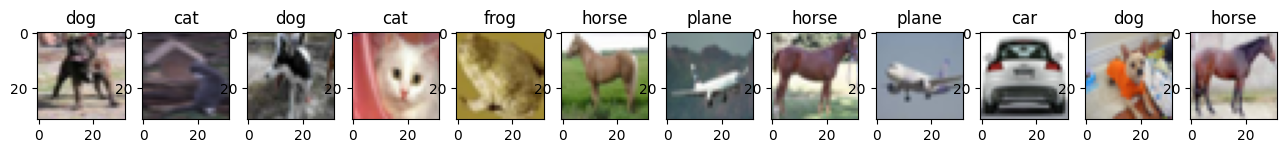

In [8]:
n_display = 12
random_ids = np.random.choice(len(x_train), n_display, replace=False)
f, axarr = plt.subplots(1,n_display,figsize=(16,16))
for k in range(n_display):
    axarr[k].imshow(x_train_initial[random_ids[k]])
    axarr[k].title.set_text(classes[y_train[random_ids[k]][0]])

In [9]:
from keras.utils import to_categorical
y_train = to_categorical(y_train)
y_val = to_categorical(y_val)
y_test = to_categorical(y_test)

print("Dimension des matrices d'étiquette de classe (train) :",y_train.shape)
print("Dimension des matrices d'étiquette de classe (val) :",y_val.shape)
print("Dimension des matrices d'étiquette de classe (test) :",y_test.shape)

Dimension des matrices d'étiquette de classe (train) : (5000, 10)
Dimension des matrices d'étiquette de classe (val) : (1000, 10)
Dimension des matrices d'étiquette de classe (test) : (1000, 10)


### II.2. Definition de l'architecture du CNN

Un simple réseau convolutionnel...

partie 6 : Approfondissement du modèle

In [10]:
from keras.models import Sequential, Model
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation, Input
from keras.regularizers import l2

model = Sequential()

# Adding an Input layer explicitly as suggested by the warning
model.add(Input(shape=(32,32,3)))

# Bloc 1
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Bloc 2
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Bloc 3
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Classification
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

On enregistre les poids initiaux pour plus tard...

In [11]:
weights_init = model.get_weights()

### II.3. Definition de la fonction de coût et choix de l'algorithme d'optimisation

Trainable paramCe sont tous les paramètres que le réseau apprend automatiquement :

In [12]:
from keras.optimizers import Adam, SGD

#opt = SGD(learning_rate=0.01,momentum=0.0)
# opt = Adam(lr=0.001)
opt = SGD(learning_rate=0.01,momentum=0.9)
model.compile(optimizer=opt,
             loss='categorical_crossentropy',
             metrics=['acc'])

On affiche un résumé de la structure du modèle...

In [13]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

None


### II.4. Entraînement du CNN

*Definition du callback. A passer en première lecture.*

Batch :
-> Sous-ensemble de données utilisé pour une mise à jour des poids
/Step:
-> Une mise à jour des poids après un batch
/Epoch:
-> Un passage complet sur toutes les données d’entraînement

QST N°2:La taille du batch joue sur la vitesse et le comportement de l’apprentissage : un petit batch est plus lent et donne des résultats un peu instables, mais il généralise souvent mieux. Un grand batch est plus rapide et plus stable, mais peut donner un modèle moins performant sur de nouvelles données.

QST N°3 : Adam converge plus rapidement, tandis que SGD est plus lent mais peut offrir une meilleure généralisation. L’ajout du momentum améliore nettement les performances de SGD

HYPERPARAMETRES:
Les hyperparamètres du modèle sont les paramètres fixés avant l’entraînement. Dans ce cas, on retrouve :

**le learning rate (0.01)**, qui détermine la vitesse à laquelle le modèle apprend
**le momentum (0.0**), qui peut aider à accélérer la convergence
**le batch size (32)**, qui correspond au nombre d’exemples utilisés à chaque étape d’apprentissage
**le nombre d’époques (20)**, qui indique combien de fois le modèle parcourt les données
**le nombre de filtres (8)**, qui influence la capacité du réseau à extraire des caractéristiques
**la taille du noyau (3×3)**, qui définit la zone analysée par les filtres
**le dropout (0.0)** et la **régularisation L2 (0.00)**, qui servent à limiter le surapprentissage

In [14]:
from keras.callbacks import Callback
from keras.callbacks import ModelCheckpoint
import time

class TimeHistory(Callback):
    def on_train_begin(self, logs={}):
        self.times = []

    def on_epoch_begin(self, batch, logs={}):
        self.epoch_time_start = time.time()

    def on_epoch_end(self, batch, logs={}):
        self.times.append(time.time() - self.epoch_time_start)
time_callback = TimeHistory()
filepath = "my_model.h5"
checkpoint = ModelCheckpoint(filepath, monitor='val_acc', verbose=1, save_best_only=True, mode='max', save_freq='epoch')

callbacks = [time_callback, checkpoint]

In [15]:
history = model.fit(x_train, y_train, batch_size=32, epochs=20, verbose=1, validation_data=(x_val, y_val),
                    callbacks=callbacks)

Epoch 1/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - acc: 0.1562 - loss: 2.2474
Epoch 1: val_acc improved from None to 0.29400, saving model to my_model.h5



Epoch 1: finished saving model to my_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 97ms/step - acc: 0.1978 - loss: 2.1644 - val_acc: 0.2940 - val_loss: 1.9553
Epoch 2/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - acc: 0.2886 - loss: 1.9465
Epoch 2: val_acc improved from 0.29400 to 0.38100, saving model to my_model.h5



Epoch 2: finished saving model to my_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step - acc: 0.3206 - loss: 1.8940 - val_acc: 0.3810 - val_loss: 1.7184
Epoch 3/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - acc: 0.3671 - loss: 1.7564
Epoch 3: val_acc improved from 0.38100 to 0.38800, saving model to my_model.h5



Epoch 3: finished saving model to my_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 87ms/step - acc: 0.3754 - loss: 1.7160 - val_acc: 0.3880 - val_loss: 1.6553
Epoch 4/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - acc: 0.4094 - loss: 1.6172
Epoch 4: val_acc improved from 0.38800 to 0.48200, saving model to my_model.h5



Epoch 4: finished saving model to my_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - acc: 0.4230 - loss: 1.5764 - val_acc: 0.4820 - val_loss: 1.4630
Epoch 5/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - acc: 0.4805 - loss: 1.4572
Epoch 5: val_acc improved from 0.48200 to 0.50400, saving model to my_model.h5


...


Epoch 8: finished saving model to my_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - acc: 0.5930 - loss: 1.1584 - val_acc: 0.5530 - val_loss: 1.3247
Epoch 9/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - acc: 0.6433 - loss: 1.0275
Epoch 9: val_acc improved from 0.55300 to 0.56300, saving model to my_model.h5



Epoch 9: finished saving model to my_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - acc: 0.6450 - loss: 1.0150 - val_acc: 0.5630 - val_loss: 1.3774
Epoch 10/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - acc: 0.6626 - loss: 0.9337
Epoch 10: val_acc did not improve from 0.56300
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - acc: 0.6618 - loss: 0.9450 - val_acc: 0.5480 - val_loss: 1.4227
Epoch 11/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - acc: 0.6848 - loss: 0.8943
Epoch 11: val_acc improved from 0.56300 to 0.56700, saving model to my_model.h5



Epoch 11: finished saving model to my_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - acc: 0.6800 - loss: 0.8991 - val_acc: 0.5670 - val_loss: 1.3062
Epoch 12/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - acc: 0.7339 - loss: 0.7680
Epoch 12: val_acc improved from 0.56700 to 0.59000, saving model to my_model.h5



Epoch 12: finished saving model to my_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 85ms/step - acc: 0.7246 - loss: 0.7851 - val_acc: 0.5900 - val_loss: 1.3467
Epoch 13/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - acc: 0.7678 - loss: 0.6638
Epoch 13: val_acc did not improve from 0.59000
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step - acc: 0.7514 - loss: 0.7115 - val_acc: 0.5770 - val_loss: 1.4911
Epoch 14/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - acc: 0.7969 - loss: 0.5649
Epoch 14: val_acc did not improve from 0.59000
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 87ms/step - acc: 0.7700 - loss: 0.6291 - val_acc: 0.5650 - val_loss: 1.4811
Epoch 15/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - acc: 0.7905 - loss: 0.6081
Epoch 15: val_acc improved from 0.59000 to 0.59600, saving model to my_model.h5



Epoch 15: finished saving model to my_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - acc: 0.7840 - loss: 0.6166 - val_acc: 0.5960 - val_loss: 1.4916
Epoch 16/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - acc: 0.8019 - loss: 0.5471
Epoch 16: val_acc did not improve from 0.59600
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - acc: 0.7934 - loss: 0.5774 - val_acc: 0.5770 - val_loss: 1.4803
Epoch 17/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - acc: 0.8122 - loss: 0.5341
Epoch 17: val_acc did not improve from 0.59600
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - acc: 0.8152 - loss: 0.5221 - val_acc: 0.5620 - val_loss: 1.6923
Epoch 18/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - acc: 0.8289 - loss: 0.4682
Epoch 18: val_acc did not improve from 0.59600
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - acc: 0.8212 - loss: 0.5033 - val_acc: 0.5470 - val_loss: 1.6398
Epoch 19/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - acc: 0.8453 - loss: 0.4398
Epoch 19: val_acc did not improve from 0.59

Statistiques sur le temps d'entraînement d'une epoch

In [16]:
times = time_callback.times
print("Mean: {}".format(np.mean(times)))
print("Std: {}".format(np.std(times)))

Mean: 15.904456841945649
Std: 2.9263890757229274


Tracé des courbes d'évolution des fonctions de coût

In [17]:
history.history.keys()

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])

6/qst 2:
Affichage des résulats

Partie 6/ QST 3:L’approfondissement du réseau a permis d’améliorer les performances du modèle en capturant des caractéristiques plus complexes. Cependant, cela augmente aussi le coût de calcul et le risque de surapprentissage. Des optimisations supplémentaires peuvent encore être apportées pour améliorer la généralisation.

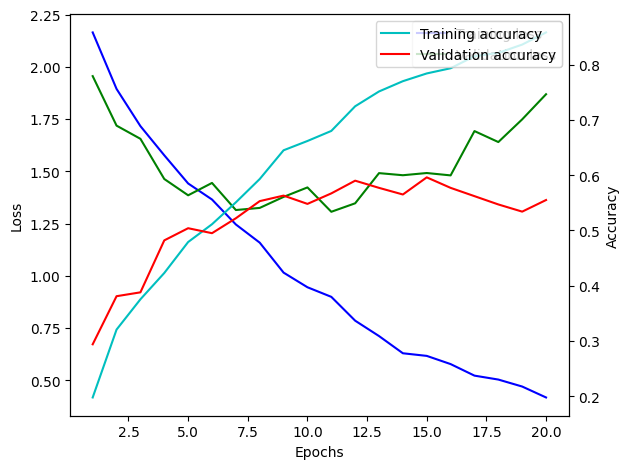

In [18]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc_values = history_dict['acc']
val_acc_values = history_dict['val_acc']

epochs = range(1, len(history_dict['acc']) + 1)

fig, ax1 = plt.subplots()
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.plot(epochs, loss_values, color='b', label='Training loss')
ax1.plot(epochs, val_loss_values, color='g', label='Validation loss')
ax1.tick_params(axis='y')
plt.legend()

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

ax2.set_ylabel('Accuracy')  # we already handled the x-label with ax1
ax2.plot(epochs, acc_values, color='c', label='Training accuracy')
ax2.plot(epochs, val_acc_values, color='r', label='Validation accuracy')
ax2.tick_params(axis='y')

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.legend(loc=1)
plt.show()

***QST N°2***:Comment l’observer sur les courbes ?
On analyse généralement : fonction de coût/accuracy
pour train et validation
La loss d’entraînement diminue continuellement
La loss de validation diminue au début puis augmente
=> Le sur-apprentissage apparaît lorsque le modèle apprend trop bien les données d’entraînement, mais généralise mal sur les données de validation.


***QST N°3:*** Le sur-apprentissage peut être réduit grâce à des techniques comme le dropout, la régularisation L2 ou la data augmentation. On peut aussi utiliser l’early stopping pour arrêter l’entraînement au bon moment. Ces méthodes permettent d’améliorer la généralisation du modèle et de réduire l’écart entre train et validation.

### II.5. Entraînement d'un CNN avec points d'arrêt et reprises (à passer en première lecture)

Pour des entraînements plus conséquents, il est primordial d'enregistrer les modèles intermédiaires afin de ne pas tout perdre si l'apprentissage venait à s'interrompre de façon impromptue. On peut enregistrer le modèle dans un fichier .hdf

Si vous regardez plus attentivement, lors de l'entrainement précédent nous avons crée un object **ModelCheckpoint**. Il permet d'enregistrer le meilleur modèle (au sens d'une metrique à préciser) dans un fichier nommé *my_model.h5*. Verifiez que ce fichier se trouve bien votre espace de travail.

L'argument ***period*** de l'objet ModelCheckpoint vous permet de definir la fréquence des enregistrements.

In [19]:
from keras.models import load_model

Une fois le modele obtenu, on peut l'enregister et le recharger comme ceci: load_model(filepath)

In [20]:
from keras.models import load_model
from keras.optimizers import SGD # Ensure SGD is imported for re-instantiation

import pathlib
file = pathlib.Path(filepath)
if file.exists():
    model = load_model(filepath)
    # Recreate the optimizer instance after loading the model
    # The original opt was SGD(learning_rate=0.01,momentum=0.0)
    opt = SGD(learning_rate=0.01, momentum=0.0) # Re-instantiate the optimizer
    model.compile(optimizer=opt, # Use the new optimizer instance
                 loss='categorical_crossentropy',
                 metrics=['acc'])
else:
    model.set_weights(weights_init)
    # Recreate the optimizer instance after setting initial weights
    opt = SGD(learning_rate=0.01, momentum=0.0) # Re-instantiate the optimizer
    model.compile(optimizer=opt, # Use the new optimizer instance
                 loss='categorical_crossentropy',
                 metrics=['acc'])
    callbacks = [time_callback,checkpoint]
history_2 = model.fit(x_train, y_train, batch_size=8, epochs=10, verbose=1, validation_data=(x_val, y_val),
                      callbacks = callbacks)

Epoch 1/10
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - acc: 0.8738 - loss: 0.3744
Epoch 1: val_acc did not improve from 0.59600
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - acc: 0.8738 - loss: 0.3580 - val_acc: 0.5870 - val_loss: 1.5583
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9061 - loss: 0.2649
Epoch 2: val_acc did not improve from 0.59600
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - acc: 0.9114 - loss: 0.2494 - val_acc: 0.5800 - val_loss: 1.7282
Epoch 3/10
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9296 - loss: 0.2040
Epoch 3: val_acc did not improve from 0.59600
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - acc: 0.9296 - loss: 0.2142 - val_acc: 0.5910 - val_loss: 1.8168
Epoch 4/10
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9350 - loss: 0.1737
Epoch 4: val_acc improved from 0.59600 to 0.59800, saving model to my_model.h5



Epoch 4: finished saving model to my_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - acc: 0.9392 - loss: 0.1674 - val_acc: 0.5980 - val_loss: 1.9033
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9450 - loss: 0.1546
Epoch 5: val_acc did not improve from 0.59800
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - acc: 0.9440 - loss: 0.1568 - val_acc: 0.5910 - val_loss: 1.9117
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.9434 - loss: 0.1549
Epoch 6: val_acc did not improve from 0.59800
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - acc: 0.9484 - loss: 0.1433 - val_acc: 0.5900 - val_loss: 2.0353
Epoch 7/10
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9621 - loss: 0.1119
Epoch 7: val_acc did not improve from 0.59800
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - acc: 0.9598 - loss: 0.1191 - val_acc: 0.5960 - val_loss: 2.0846
Epoch 8/10
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9612 - loss: 0.1151
Epoch 8: val_acc did not improve from 0.59800
625/6

# III - Test et Évaluation du modèle en prédiction

### III.1. Test du modèle sur les données de test

Testons la prédiction de notre modèle sur quelques images de test au hasard...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


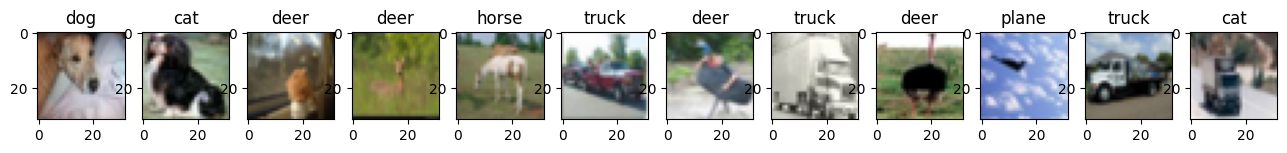

In [21]:
random_ids = np.random.choice(len(x_test), n_display, replace=False)
pred = np.argmax(model.predict(x_test[random_ids]), axis=1)
f, axarr = plt.subplots(1,n_display,figsize=(16,16))
for k in range(n_display):
    axarr[k].imshow(x_test_initial[random_ids[k]])
    axarr[k].title.set_text(classes[pred[k]])

Vos premiers résultats semblent-ils corrects ?

Hum ! Affichons à présent la précision sur l'ensemble de votre base :

In [22]:
print("Précision du réseau sur les {} images d'entraînement : {:.2f} %".format(n_training_samples, 100 * history_dict['acc'][-1]))
print("Précision du réseau sur les {} images de validation : {:.2f} %".format(n_valid, 100 * history_dict['val_acc'][-1]))

Précision du réseau sur les 5000 images d'entraînement : 85.82 %
Précision du réseau sur les 1000 images de validation : 55.50 %


In [23]:
def accuracy_per_class(model):
    n_classes = len(classes)
    confusion_matrix = np.zeros((n_classes, n_classes), dtype=np.int64)

    pred = np.argmax(model.predict(x_test), axis=1)
    for i in range(len(y_test)):
        confusion_matrix[np.argmax(y_test[i]), pred[i]] += 1

    print("{:<10} {:^10}".format("Classe", "Précision (%)"))
    total_correct = 0
    for i in range(n_classes):
        class_total = confusion_matrix[i, :].sum()
        class_correct = confusion_matrix[i, i]
        total_correct += class_correct
        percentage_correct = 100.0 * float(class_correct) / class_total
        print('{:<10} {:^10.2f}'.format(classes[i], percentage_correct))
    test_acc = 100.0 * float(total_correct) / len(y_test)
    print("Précision du réseau sur les {} images de test : {:.2f} %".format(len(y_test),test_acc))
    return confusion_matrix

confusion_matrix = accuracy_per_class(model)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
Classe     Précision (%)
plane        65.31   
car          77.32   
bird         41.24   
cat          46.88   
deer         58.70   
dog          42.48   
frog         65.66   
horse        61.68   
ship         66.67   
truck        68.69   
Précision du réseau sur les 1000 images de test : 59.30 %


### III.2. Matrices de Confusion

Les matrices de confusion nous renseignent plus précisément sur la nature des erreurs commises par notre modèle.

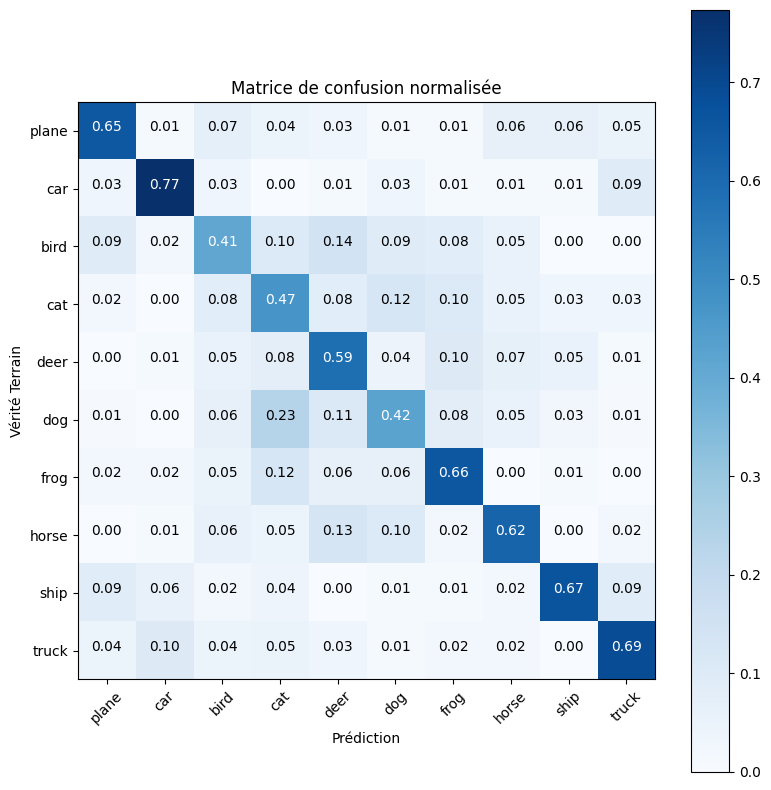

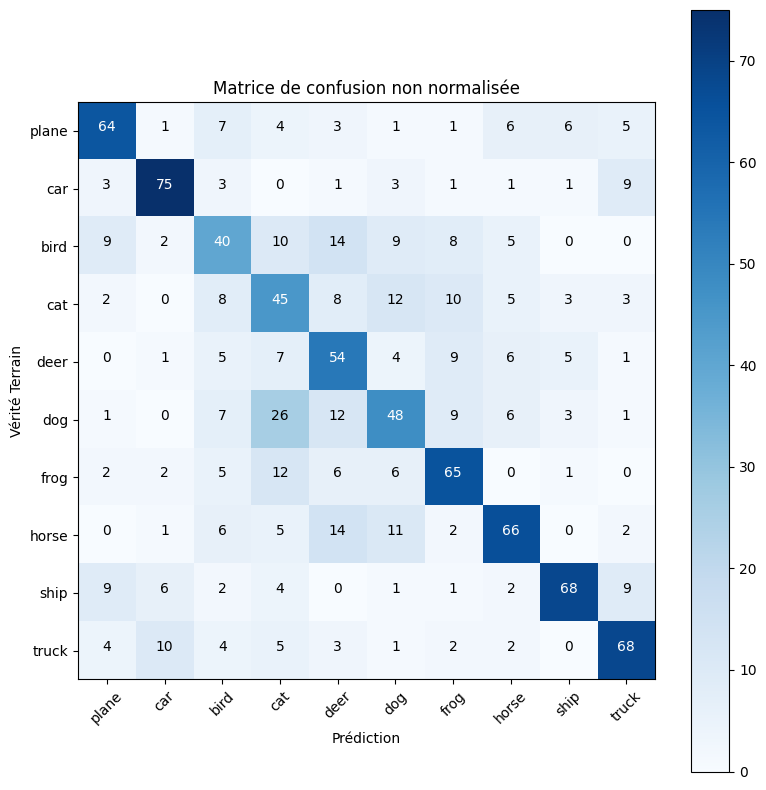

In [24]:
# Plot normalized confusion matrix
plot_confusion_matrix(confusion_matrix, classes, normalize=True,
                      title='Matrice de confusion normalisée')

# Plot non-normalized confusion matrix
plot_confusion_matrix(confusion_matrix, classes,
                      title='Matrice de confusion non normalisée')

# IV - Visualisation des zones d'activation

In [25]:
from keras.models import Model

reduced_model = Model(inputs=model.inputs, outputs=model.layers[1].output)
reduced_model.summary()

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896 (3.50 KB)

 Trainable params: 896 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
feature_maps = reduced_model.predict(x_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [27]:
def get_mask(k):
    feature_maps_positive = np.maximum(feature_maps[k], 0)
    mask = np.sum(feature_maps_positive,axis=2)
    mask = mask / np.max(mask)
    return mask

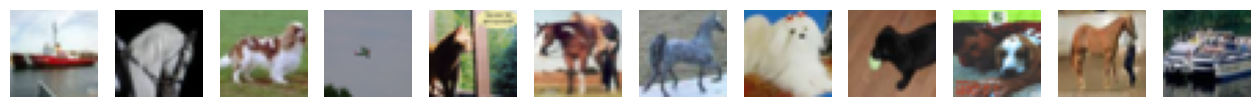

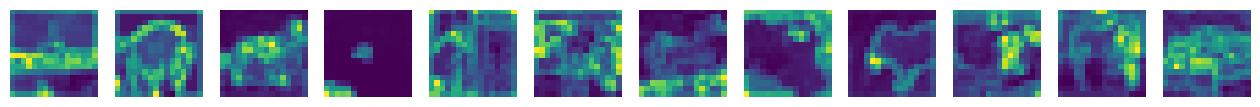

In [28]:
random_ids = np.random.choice(len(x_test), n_display, replace=False)
f, rd_img = plt.subplots(1,n_display,figsize=(16,16))
for k in range(n_display):
    img = x_test_initial[random_ids[k]]
    rd_img[k].imshow(img)
    rd_img[k].axis('off')
f, rd_maps = plt.subplots(1,n_display,figsize=(16,16))
for k in range(n_display):
    mask = get_mask(random_ids[k])
    rd_maps[k].imshow(mask)
    rd_maps[k].axis('off')

***Cartes d’activation***

Elles détectent des éléments simples comme les contours, les couleurs et les textures. Ce sont les premières caractéristiques extraites de l’image.

Couches profondes

Les cartes deviennent plus complexes et représentent des formes ou parties d’objets. Le modèle combine les informations simples pour reconnaître des structures plus avancées.

Évolution pendant l’entraînement

Au début, les cartes sont floues ou bruitées, puis elles deviennent plus claires. Cela montre que le modèle apprend progressivement des caractéristiques utiles.